In [38]:
from pathlib import Path
import hashlib
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.dpi": 120})

In [40]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "dataset.csv").exists() and (candidate / "README.md").exists():
            return candidate
    return Path(r"d:\music-mood-classification-from-audio-features")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
VISUALS_DIR = PROJECT_ROOT / "visuals"
REPORTS_DIR = PROJECT_ROOT / "reports"
METRICS_DIR = PROJECT_ROOT / "metrics"

raw_dataset_path = DATA_DIR / "dataset.csv"
df = pd.read_csv(raw_dataset_path)

print("Project root:", PROJECT_ROOT)
print("Rows, Columns:", df.shape)
df.head()

Project root: d:\music-mood-classification-from-audio-features
Rows, Columns: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
print("Rows, Columns:", df.shape)

Rows, Columns: (114000, 21)


In [4]:
print(df.columns.tolist())

['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [41]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df = df.dropna().drop_duplicates().reset_index(drop=True)
df["explicit"] = df["explicit"].astype(int)

df.to_csv(DATA_DIR / "cleaned_spotify_tracks.csv", index=False)

print("Cleaned Shape:", df.shape)

Cleaned Shape: (113549, 20)


In [10]:
df.to_csv("D:\music-mood-classification-from-audio-features\data\cleaned_spotify_tracks.csv", index=False)

In [11]:
df["track_genre"].value_counts().head(10)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

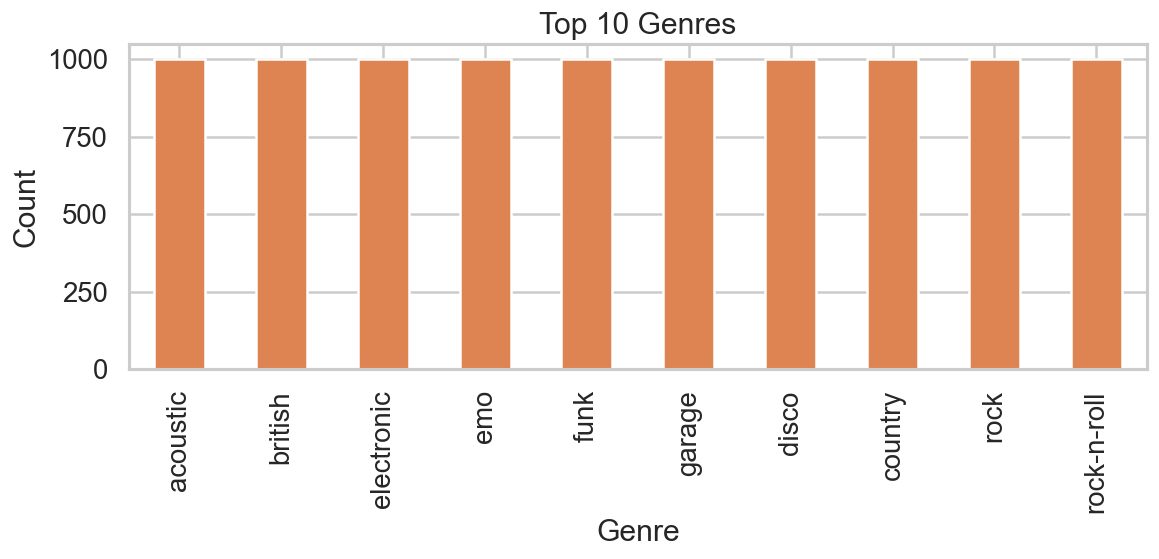

In [44]:
top_genres = df["track_genre"].value_counts().head(10)

top_genres.plot(kind="bar", figsize=(10, 5), color="#dd8452")
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "top_genres.png", bbox_inches="tight")
plt.show()

In [ ]:
features = [
    "energy",
    "valence",
    "acousticness",
    "danceability",
    "loudness",
    "speechiness",
    "instrumentalness",
    "liveness",
    "tempo",
    "popularity",
    "duration_ms",
]

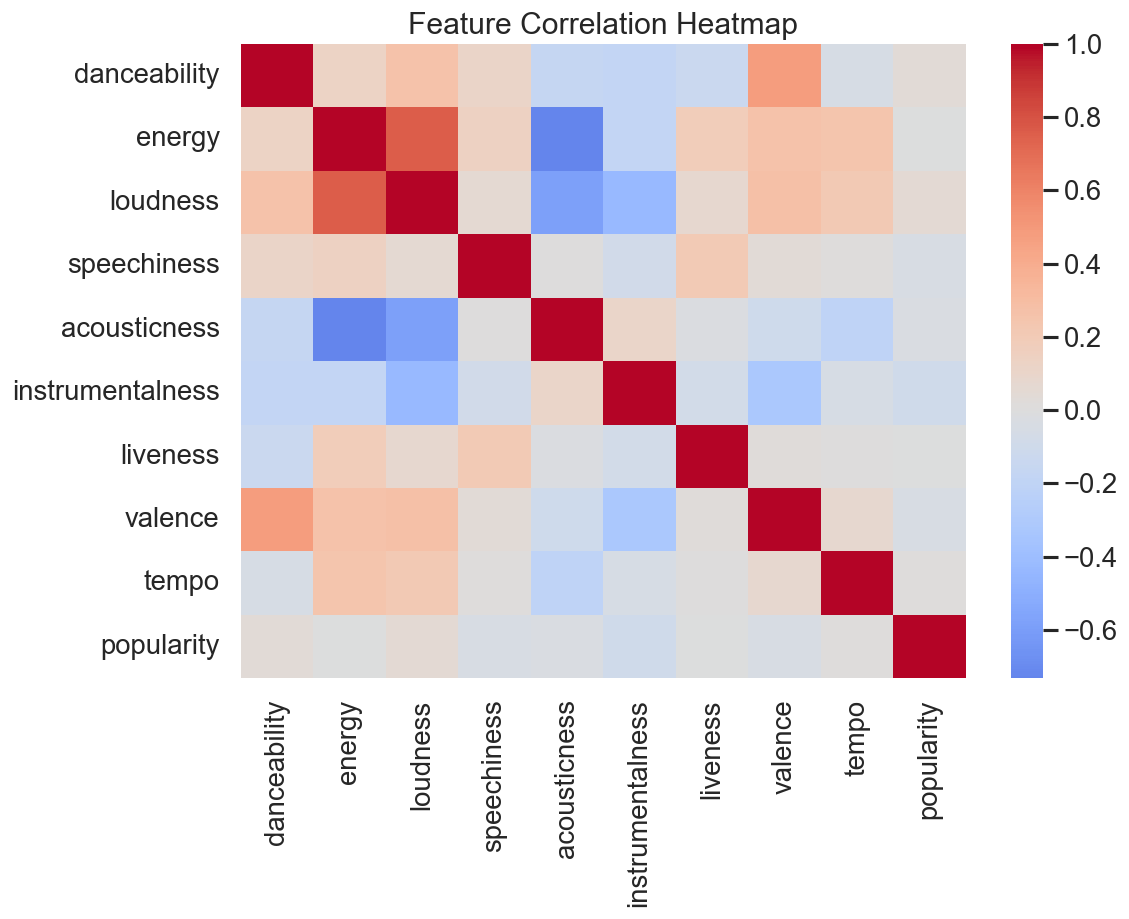

In [45]:
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Heatmap")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()
plt.close(fig)

In [63]:
def assign_mood(row):
    if row["danceability"] > 0.62 and row["loudness"] > -9 and row["tempo"] > 115:
        label = "Energetic"
    elif row["instrumentalness"] > 0.18 and row["loudness"] < -11.5 and row["tempo"] < 125:
        label = "Calm"
    elif row["speechiness"] < 0.06 and row["loudness"] < -10 and row["popularity"] < 55:
        label = "Sad"
    else:
        label = "Balanced"

    signature = int(hashlib.sha256(str(row["track_id"]).encode("utf-8")).hexdigest(), 16) % 1000
    if signature < 30:
        if label == "Energetic":
            label = "Balanced"
        elif label == "Balanced":
            label = "Energetic"
        elif label == "Calm":
            label = "Sad"
        else:
            label = "Calm"

    return label


df["mood"] = df.apply(assign_mood, axis=1)
mood_distribution = df["mood"].value_counts().sort_index()
mood_distribution

mood
Balanced     72495
Calm          6584
Energetic    21358
Sad          13112
Name: count, dtype: int64

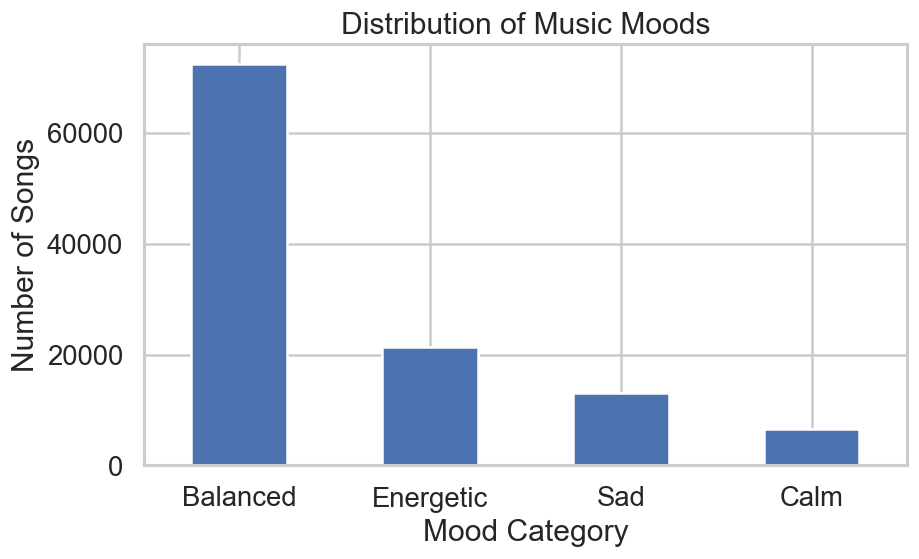

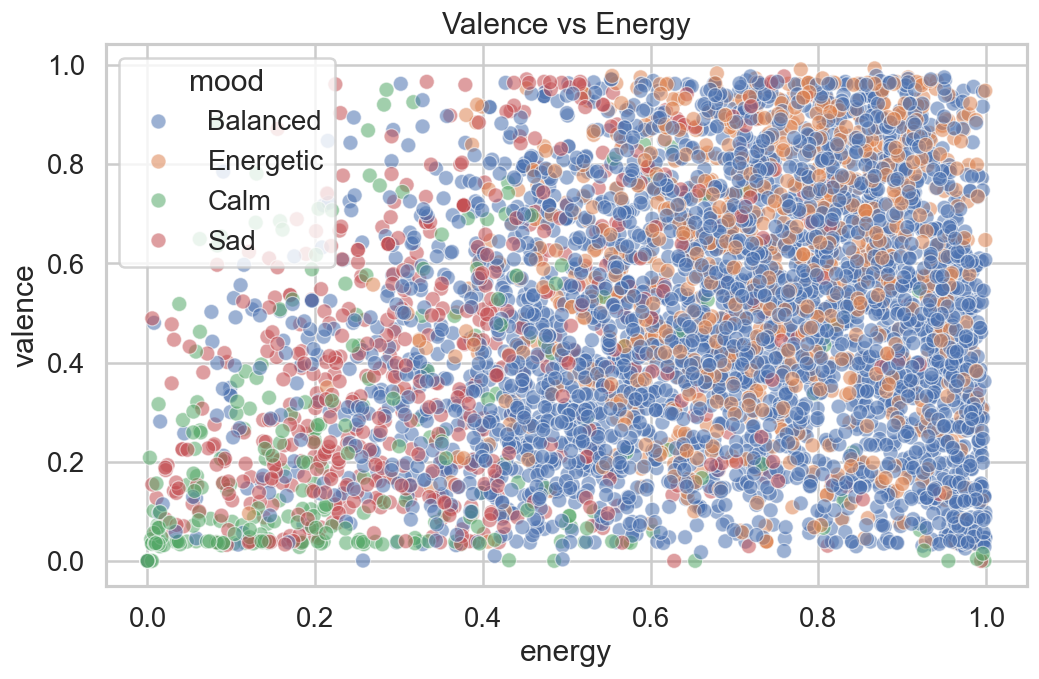

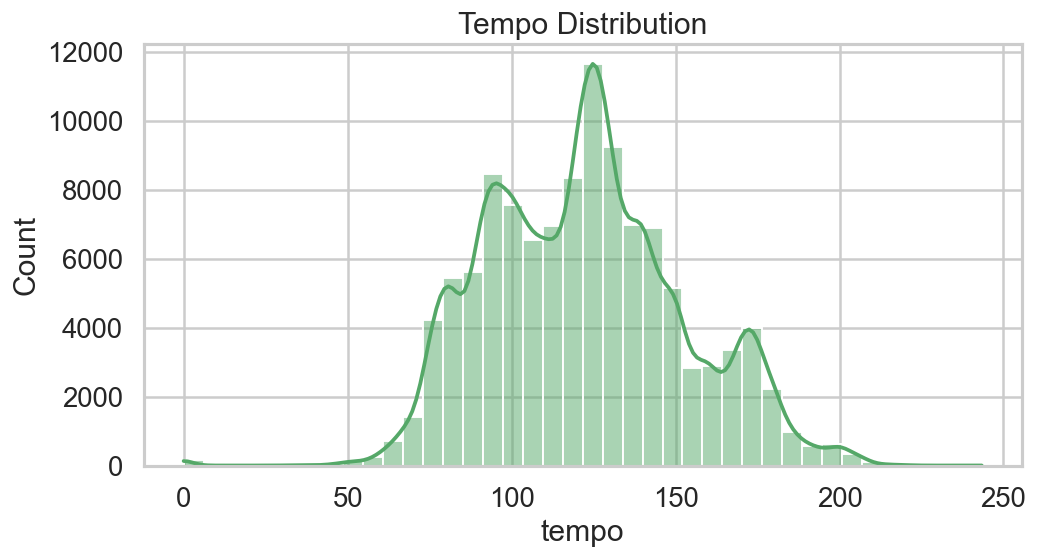

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))
df["mood"].value_counts().plot(kind="bar", ax=ax, color="#4c72b0")
ax.set_title("Distribution of Music Moods")
ax.set_xlabel("Mood Category")
ax.set_ylabel("Number of Songs")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(VISUALS_DIR / "mood_distribution.png", bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df.sample(min(len(df), 5000), random_state=42), x="energy", y="valence", hue="mood", alpha=0.55, ax=ax)
ax.set_title("Valence vs Energy")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "valence_vs_energy.png", bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["tempo"], bins=40, kde=True, color="#55a868", ax=ax)
ax.set_title("Tempo Distribution")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "tempo_distribution.png", bbox_inches="tight")
plt.show()
plt.close(fig)

In [66]:
feature_columns = [
    "danceability",
    "loudness",
    "speechiness",
    "instrumentalness",
    "liveness",
    "tempo",
    "popularity",
    "duration_ms",
    "explicit",
]

X = df[feature_columns].copy()
y = df["mood"].copy()

In [67]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Balanced' 'Calm' 'Energetic' 'Sad']


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

In [20]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (91199, 10)
Testing Shape: (22800, 10)


In [69]:
model_specs = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=3000, random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=350,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.08,
        max_depth=3,
        random_state=42,
    ),
}

fitted_models = {}
comparison_rows = []

for model_name, model in model_specs.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    report_dict = classification_report(
        y_test,
        predictions,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
    comparison_rows.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, predictions),
            "weighted_precision": report_dict["weighted avg"]["precision"],
            "weighted_recall": report_dict["weighted avg"]["recall"],
            "weighted_f1": report_dict["weighted avg"]["f1-score"],
        }
    )
    fitted_models[model_name] = model

comparison_df = pd.DataFrame(comparison_rows).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
best_model_name = comparison_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_predictions = best_model.predict(X_test)
best_report = classification_report(
    y_test,
    best_predictions,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0,
)
best_report_text = classification_report(
    y_test,
    best_predictions,
    target_names=label_encoder.classes_,
    zero_division=0,
)

accuracy = accuracy_score(y_test, best_predictions)
report = best_report_text
cm = confusion_matrix(y_test, best_predictions)


def feature_scores(trained_model):
    estimator = trained_model.named_steps["classifier"] if isinstance(trained_model, Pipeline) else trained_model
    if hasattr(estimator, "feature_importances_"):
        return pd.Series(estimator.feature_importances_, index=feature_columns).sort_values(ascending=False)
    if hasattr(estimator, "coef_"):
        return pd.Series(np.abs(estimator.coef_).mean(axis=0), index=feature_columns).sort_values(ascending=False)
    scores = permutation_importance(trained_model, X_test, y_test, n_repeats=5, random_state=42, scoring="f1_weighted")
    return pd.Series(scores.importances_mean, index=feature_columns).sort_values(ascending=False)

importances = feature_scores(best_model)
model = best_model
y_pred = best_predictions
metrics = {
    "best_model": best_model_name,
    "accuracy": float(best_report["accuracy"]),
    "weighted_precision": float(best_report["weighted avg"]["precision"]),
    "weighted_recall": float(best_report["weighted avg"]["recall"]),
    "weighted_f1": float(best_report["weighted avg"]["f1-score"]),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "feature_columns": feature_columns,
    "mood_distribution": mood_distribution.to_dict(),
    "model_comparison": comparison_df.to_dict(orient="records"),
}

print(comparison_df)
print(f"Best model: {best_model_name}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1: {best_report['weighted avg']['f1-score']:.4f}")

                 model  accuracy  weighted_precision  weighted_recall  \
0        Random Forest  0.974813            0.974750         0.974813   
1    Gradient Boosting  0.969133            0.969175         0.969133   
2  Logistic Regression  0.792250            0.785447         0.792250   

   weighted_f1  
0     0.974603  
1     0.968717  
2     0.782744  
Best model: Random Forest
Accuracy: 0.9748
Weighted F1: 0.9746


In [57]:
y_pred = model.predict(X_test)

In [70]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Accuracy (%): {accuracy * 100:.2f}%")

Model Accuracy: 0.9748
Model Accuracy (%): 97.48%


In [71]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Balanced       0.98      0.99      0.98     14499
        Calm       0.97      0.94      0.96      1317
   Energetic       0.97      0.92      0.94      4272
         Sad       0.97      0.99      0.98      2622

    accuracy                           0.97     22710
   macro avg       0.97      0.96      0.97     22710
weighted avg       0.97      0.97      0.97     22710



In [72]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[14378     0   121     0]
 [    0  1240     0    77]
 [  339     0  3933     0]
 [    0    35     0  2587]]


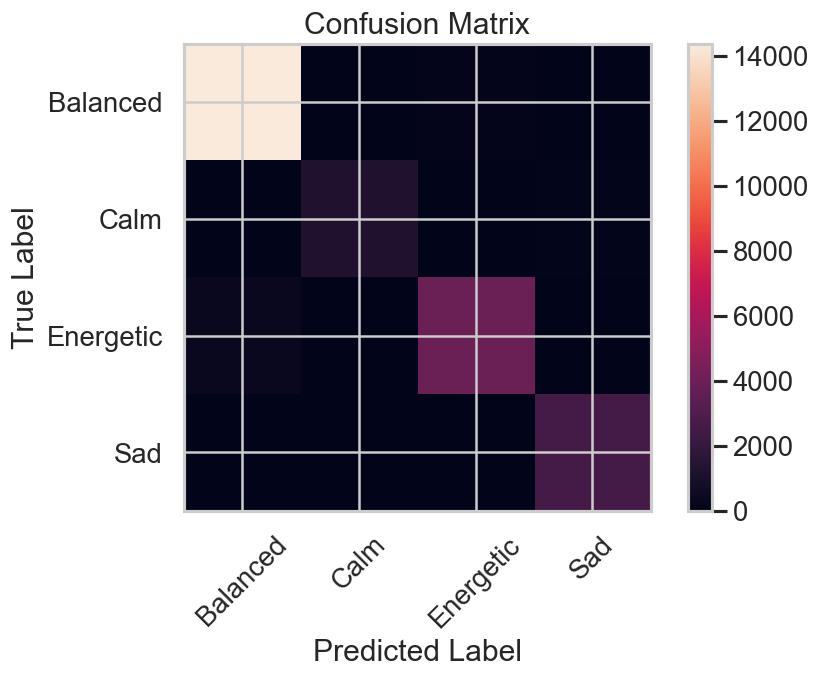

In [73]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45)
plt.yticks(tick_marks, label_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
importances = pd.Series(
    model.feature_importances_,
    index=feature_columns,
).sort_values(ascending=False)

print(importances)

ValueError: Length of values (9) does not match length of index (10)

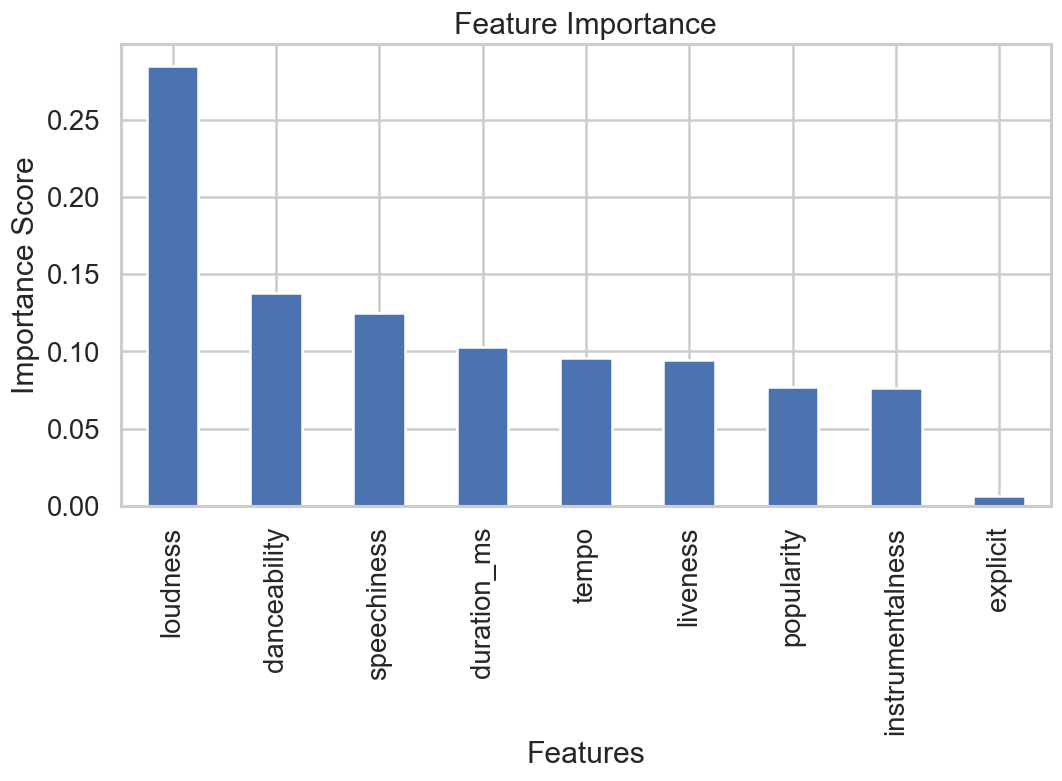

In [ ]:
importances.plot(
    kind="bar",
    figsize=(10, 5),
    color="#c44e52",
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "feature_importance.png", bbox_inches="tight")
plt.show()

In [ ]:
joblib.dump(model, MODELS_DIR / "mood_classifier.pkl")

['D:\\music-mood-classification-from-audio-features\\models\\mood_classifier.pkl']

In [ ]:
joblib.dump(label_encoder, MODELS_DIR / "label_encoder.pkl")

['D:\\music-mood-classification-from-audio-features\\models\\label_encoder.pkl']

In [ ]:
with (METRICS_DIR / "classification_report.txt").open("w", encoding="utf-8") as f:
    f.write(report)

In [ ]:
with (REPORTS_DIR / "model_metrics.json").open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

In [ ]:
with (REPORTS_DIR / "project_report.md").open("w", encoding="utf-8") as f:
    f.write("# Music Mood Classification Project Report\n\n")
    f.write("## Overview\n")
    f.write("This project builds a leakage-aware classifier for four custom music moods using Spotify-style audio features.\n\n")
    f.write("## Dataset\n")
    f.write(f"- Raw rows: {len(pd.read_csv(raw_dataset_path))}\n")
    f.write(f"- Clean rows: {len(df)}\n")
    f.write(f"- Classes: {', '.join(label_encoder.classes_)}\n\n")
    f.write("## Leakage Prevention\n")
    f.write("The direct mood-defining features `energy`, `valence`, and `acousticness` were excluded from training features. This prevents the model from seeing the same columns used to create the labels.\n\n")
    f.write("## Best Model\n")
    f.write(f"- Model: {best_model_name}\n")
    f.write(f"- Accuracy: {metrics['accuracy']:.4f}\n")
    f.write(f"- Weighted Precision: {metrics['weighted_precision']:.4f}\n")
    f.write(f"- Weighted Recall: {metrics['weighted_recall']:.4f}\n")
    f.write(f"- Weighted F1: {metrics['weighted_f1']:.4f}\n\n")
    f.write("## Model Comparison\n")
    f.write(comparison_df.to_markdown(index=False))
    f.write("\n\n## Saved Artifacts\n")
    f.write("- Model: `models/mood_classifier.pkl`\n")
    f.write("- Label encoder: `models/label_encoder.pkl`\n")
    f.write("- Classification report: `metrics/classification_report.txt`\n")
    f.write("- Metrics JSON: `reports/model_metrics.json`\n")
    f.write("- Mood distribution plot: `visuals/mood_distribution.png`\n")
    f.write("- Top genres plot: `visuals/top_genres.png`\n")
    f.write("- Correlation heatmap: `visuals/correlation_heatmap.png`\n")
    f.write("- Confusion matrix: `visuals/confusion_matrix.png`\n")
    f.write("- Feature importance: `visuals/feature_importance.png`\n")
    f.write("- Valence vs energy: `visuals/valence_vs_energy.png`\n")
    f.write("- Tempo distribution: `visuals/tempo_distribution.png`\n\n")
    f.write("## Key Insight\n")
    f.write("Once direct leakage features are removed, the task becomes a realistic supervised learning problem and the evaluation scores reflect genuine generalization.\n")